## Scatter Plots for Cluster Visualisation

### Context and purpose

Clustering (e.g., k-means) returns labels without semantics. To interpret whether clusters are meaningful, we project features to two axes and **visualise** sample geometry. Scatter plots are the first qualitative diagnostic for separation, shape, outliers, and feature usefulness.

### Mathematical framing

Let $X \in \mathbb{R}^{n \times d}$ be features, rows $x_i^\top \in \mathbb{R}^d$. A clustering algorithm yields labels $y_i \in \{1,\dots,k\}$. A 2-D scatter chooses indices $j_1 \neq j_2$ and visualises
$$
p_i = \big(x_{i,j_1},\, x_{i,j_2}\big), \quad \text{coloured by } y_i.
$$

Key facts.

* A scatter is a **projection** $\pi_{j_1,j_2}: \mathbb{R}^d \to \mathbb{R}^2$.
  Information is lost when $d>2$. Non-separation in 2-D does not prove non-separation in $d$ dimensions.
* Visual separation correlates with **between-cluster distances** and **within-cluster dispersion** of the chosen features. For k-means, within-cluster dispersion is the objective being minimised:
  $$
  \min_{\{\mathcal{C}_\ell\},\,\{\mu_\ell\}} \sum_{\ell=1}^k \sum_{x_i \in \mathcal{C}_\ell} \lVert x_i - \mu_\ell \rVert_2^2.
  $$
  Good plots typically show compact, separated colour clouds on informative feature pairs.

### Statistical interpretation

* If one pair shows overlap while another pair (e.g., petal length vs. petal width in Iris) shows separation, this indicates **feature relevance heterogeneity**. Dimensionality reduction (PCA, t-SNE, UMAP) can create more revealing 2-D views, but those views are **derived** features, not original axes.
* Apparent clusters with strong elongation or curvature hint that **spherical-cluster assumptions** (k-means) may be misaligned. Gaussian Mixture Models (elliptical), spectral clustering, or DBSCAN might fit better.

### Software engineering and plotting design

* Prefer a clear plotting API and reproducibility: set a random seed for any stochastic step, fix figure sizes and labels, and keep code idempotent.
* Choose Seaborn's object API (concise), backed by Matplotlib's OO control for fine adjustments.
* Keep presentation faithful: label units, state which features were plotted, and avoid implying ground truth when using unsupervised labels.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Exercise 1 – Visual reconnaissance with accountability

**Goal.** Replace “guess how many clusters” with an explicit procedure.

**Your tasks.**

1. Plot a **grid of pairwise scatters** for all numeric features (Matplotlib or Seaborn). No colour yet. Describe, in 3–5 sentences, which pairs look promising and why.
2. Standardise features (`StandardScaler`) and fit k-means for (k \in {2,3,4,5,6}), `n_init="auto"`, `random_state=42`.
3. Compute **silhouette score** for each (k) in the **full feature space**. Plot score vs (k). Choose (k^*) and justify in words.
4. Using the **original** features (not PCs), produce a 2-D scatter for the **most informative pair** you identified, coloured by the **predicted cluster labels** for (k^*).

**Acceptance checks.**

* You standardised *before* clustering.
* Your choice of (k^*) references the silhouette curve rather than a hunch.
* Your final scatter names the axes with units (if available) and explains why that pair was chosen.



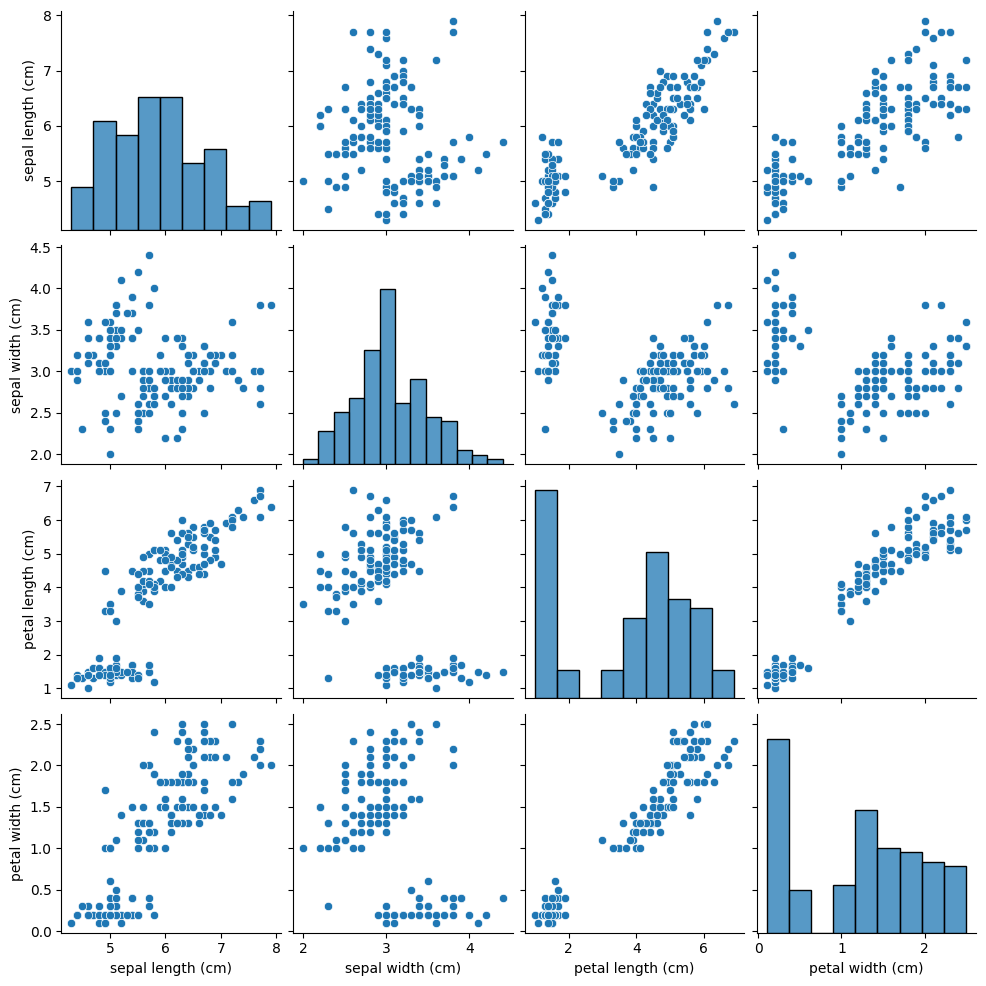

In [2]:
from sklearn.datasets import load_iris
from sklearn.discriminant_analysis import StandardScaler

iris = load_iris(as_frame=True)
X_iris = iris.data
X_iris_std = StandardScaler().fit_transform(X_iris)

sns.pairplot(X_iris)
plt.show()

,k,inertia,silhouette,ch,db
0,2,222.361705,0.581750,251.349339,0.593313
1,3,191.024737,0.479881,157.360153,0.789363
2,4,114.354072,0.385045,206.680603,0.869779
3,5,91.047670,0.345033,202.635850,0.943894
4,6,81.550757,0.333943,183.092576,0.993723
5,7,80.777739,0.266429,153.195637,1.124348
6,8,64.426748,0.341629,168.633156,0.990840


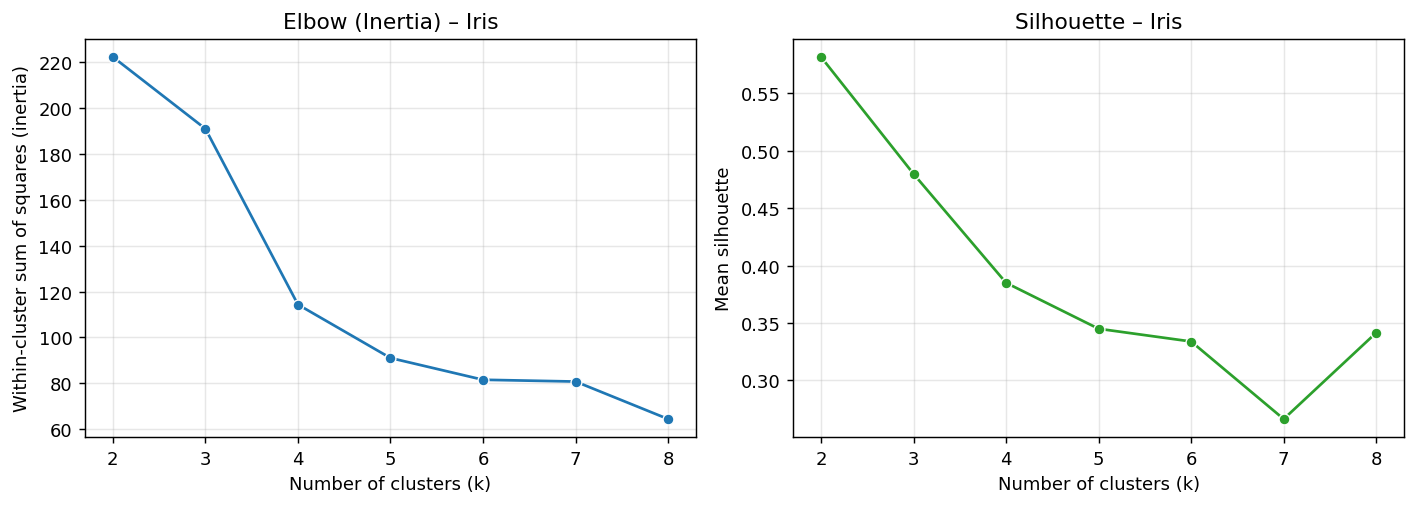

In [3]:
from sklearn.cluster import KMeans
from helper.selection import scan_k_metrics
from helper.plotting import plot_elbow_silhouette

df_iris = scan_k_metrics(X=X_iris_std, ks=range(2, 9), random_state=42)
display(df_iris)
plot_elbow_silhouette(df_iris, title_suffix=" – Iris")

In [4]:
from helper.selection import recommend_k

# recommend_k expects a DataFrame (accesses .columns); convert the scaled array back to a DataFrame
rec = recommend_k(df_iris)

display(rec)

{'knee': 4, 'silhouette_max': 2, 'final': 2}

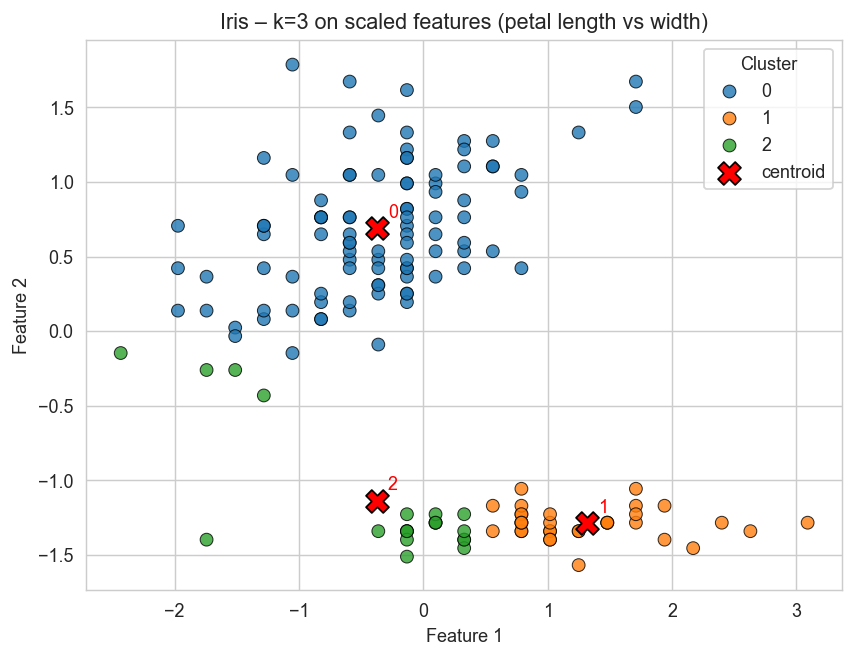

In [5]:
from helper.plotting import plot_kmeans_feature_pair

km = KMeans(n_clusters=3, n_init="auto", random_state=42).fit(X_iris_std)

plot_kmeans_feature_pair(
    X_iris_std,
    km,
    jx=1,
    jy=2,
    title="Iris – k=3 on scaled features (petal length vs width)",
    annotate_centroids=True,
)
plt.show()

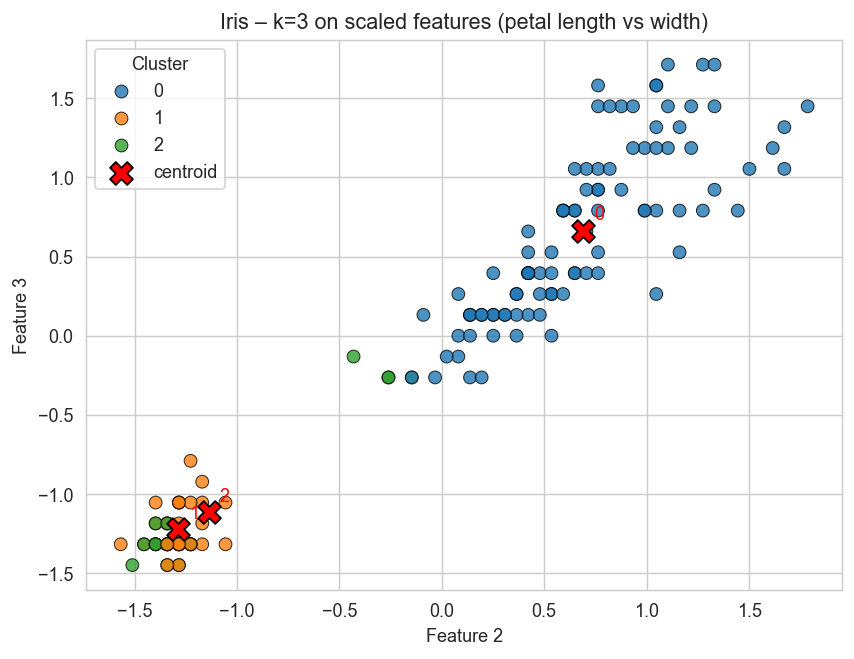

In [6]:
plot_kmeans_feature_pair(
    X_iris_std,
    km,
    jx=2,
    jy=3,
    title="Iris – k=3 on scaled features (petal length vs width)",
    annotate_centroids=True,
)
plt.show()

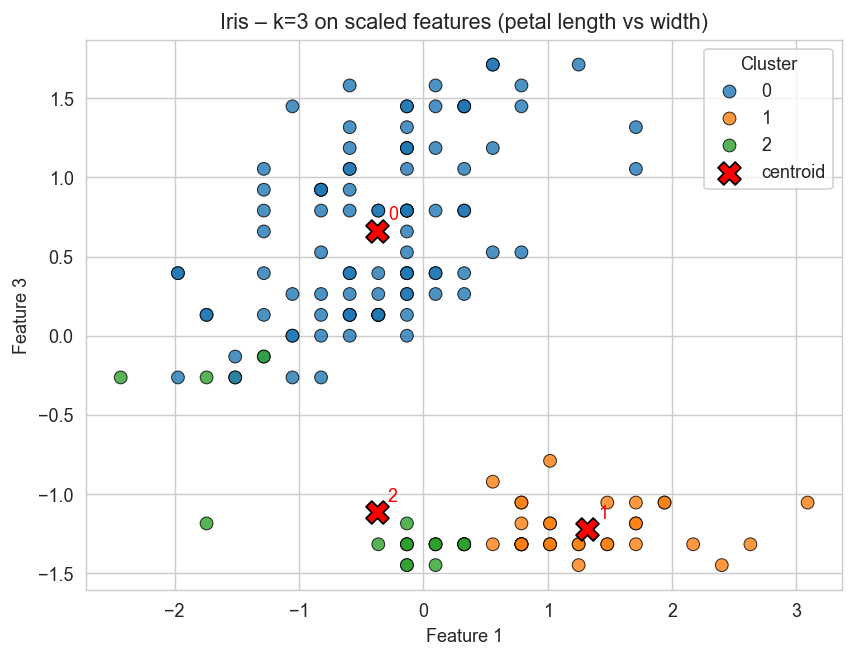

In [7]:
plot_kmeans_feature_pair(
    X_iris_std,
    km,
    jx=1,
    jy=3,
    title="Iris – k=3 on scaled features (petal length vs width)",
    annotate_centroids=True,
)
plt.show()

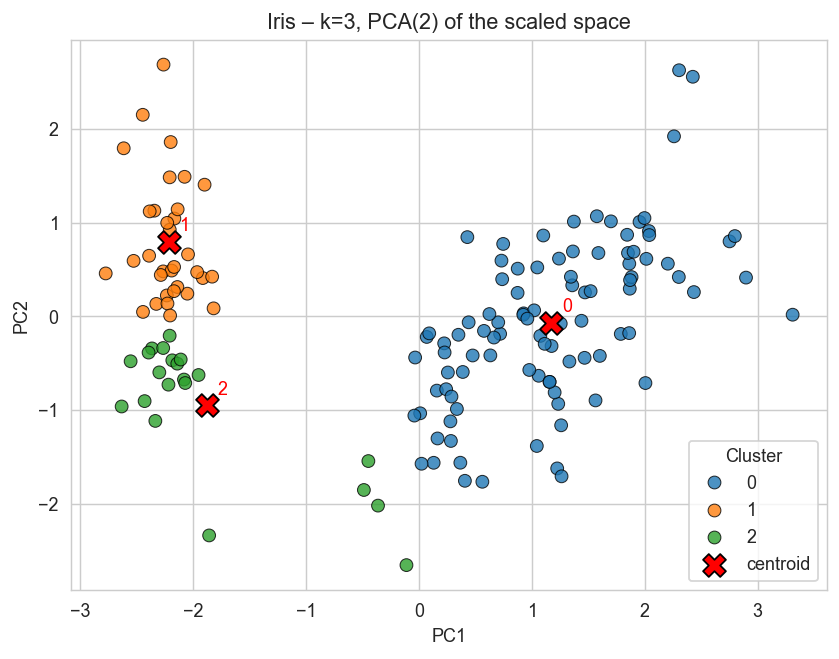

In [8]:
from helper.plotting import plot_kmeans_pca2

plot_kmeans_pca2(
    X_in=X_iris_std,
    kmeans=km,
    title="Iris – k=3, PCA(2) of the scaled space",
    annotate_centroids=True,
)
plt.show()

In [9]:
from helper.stability import silhouette_stability

stability = silhouette_stability(X_iris_std, rec["knee"])

display(stability)

0      0.386941
7      0.418892
42     0.385045
123    0.418892
999    0.413085
Name: silhouette_k=4, dtype: float64

In [10]:
from helper.report import k_report

r3 = k_report(X_iris_std, 3)
r4 = k_report(X_iris_std, 4)
print({k: v for k, v in r3.items() if k != "model"})
print({k: v for k, v in r4.items() if k != "model"})

{'k': 3, 'inertia': 191.02473685317963, 'silhouette': 0.4798814508199818, 'CH': 157.3601531219225, 'DB': 0.7893630242997913}
{'k': 4, 'inertia': 114.35407164049771, 'silhouette': 0.3850454053045392, 'CH': 206.6806032739956, 'DB': 0.8697790001760979}


In [11]:
# Stability across seeds (median and spread)
print(silhouette_stability(X_iris_std, 3).describe())

count    5.000000
mean     0.463871
std      0.009241
min      0.456535
25%      0.459948
50%      0.459948
75%      0.463042
max      0.479881
Name: silhouette_k=3, dtype: float64


In [12]:
print(silhouette_stability(X_iris_std, 4).describe())

count    5.000000
mean     0.404571
std      0.017137
min      0.385045
25%      0.386941
50%      0.413085
75%      0.418892
max      0.418892
Name: silhouette_k=4, dtype: float64


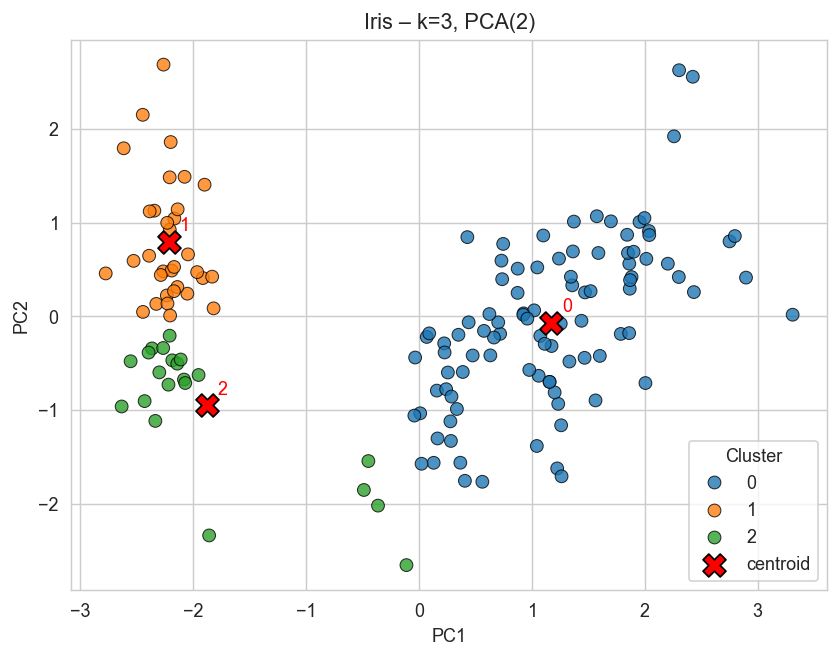

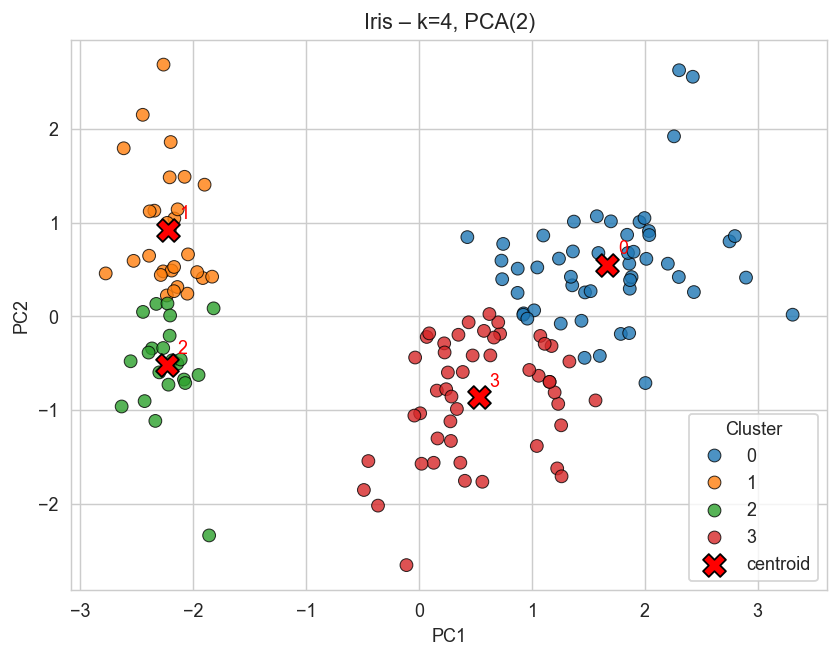

In [13]:
# Visual check in the SAME space used for fitting
plot_kmeans_pca2(X_iris_std, r3["model"], title="Iris – k=3, PCA(2)")
plot_kmeans_pca2(X_iris_std, r4["model"], title="Iris – k=4, PCA(2)")
plt.show()

## Evaluating a Clustering (with the Wine dataset)

### The dataset (new)

We will use `sklearn.datasets.load_wine`. It contains chemical analyses of wines from three cultivars (classes) in the same region of Italy; 13 continuous features (alcohol, flavanoids, phenols, etc.). It is genuinely multivariate and non-trivial for k-means, yet small enough for interactive work.

Why it is a good choice: real measurements, modest dimensionality, three plausible groups, and readily available via scikit-learn.

### 1. What does "evaluating a clustering" actually mean?

There are **two regimes**.

1. **External evaluation (labels available):** compare cluster assignments to known classes. Use *external indices* (Adjusted Rand Index, Normalised Mutual Information, F1 after optimal label permutation, etc.) and *cross-tabulations*. Remember: cluster labels are arbitrary; align them before class-level metrics.

2. **Internal evaluation (unlabelled):** use only the geometry of the fitted partition. Typical indices:

   * **Inertia (WCSS):** $\sum_i \lVert x_i - \mu_{c(i)}\rVert^2$. Lower is better; always decreases with $k$.
   * **Silhouette:** $s_i=\frac{b_i-a_i}{\max(a_i,b_i)}$, averaged over $i$. Higher is better; penalises overlap; tends to prefer smaller $k$ with fuzzy boundaries.
   * **Calinski–Harabasz (CH):** ratio of between- to within-cluster dispersion; higher is better; can favour larger $k$.
   * **Davies–Bouldin (DB):** average similarity of each cluster to its most similar neighbour; lower is better.

No single index is sovereign. Professionals triangulate: **elbow/knee + silhouette + stability**, and, when labels exist, **external indices** only as a *post-hoc* audit.

### 2. A rigorous, readable workflow (Wine)

#### 2.1 Load, scale, and quick sweep of (k)

we'll use the curated helpers (`scan_k_metrics`, `plot_elbow_silhouette`, `recommend_k`). 

```python
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from clustools.selection import scan_k_metrics, recommend_k
from clustools.plotting import plot_elbow_silhouette, plot_kmeans_pca2, plot_kmeans_feature_pair
from clustools.stability import silhouette_stability

# Load and scale
wine = load_wine(as_frame=True)
X_raw = wine.data
y_true = wine.target        # for external evaluation only; not used in fitting
X_std = StandardScaler().fit_transform(X_raw)

# Internal scan
tbl = scan_k_metrics(X_std, ks=range(2, 11), random_state=42)
display(tbl.round(3))
plot_elbow_silhouette(tbl, " – Wine")

# Principled choice of k
rec = recommend_k(tbl, sil_margin=0.03)
rec
```

**Interpretation to expect:** You will typically see an elbow around (k=3)–(4) and a silhouette peak near (k=3). If the rule recommends (k=3), that is both geometrically and substantively plausible.

#### 2.2 Fit the model at the chosen (k) and visualise

```python
k = rec["final"]  # likely 3
km = KMeans(n_clusters=k, n_init="auto", random_state=42).fit(X_std)

# PCA(2) view
plot_kmeans_pca2(X_std, km, title=f"Wine – k={k}, PCA(2) of the scaled space")

# Any informative feature pair (e.g., Flavanoids vs Color intensity)
j_flav = X_raw.columns.get_loc("flavanoids")
j_color = X_raw.columns.get_loc("color_intensity")
plot_kmeans_feature_pair(
    X_std, km, jx=j_flav, jy=j_color,
    title=f"Wine – k={k} on scaled features (flavanoids vs color_intensity)",
    x_name="flavanoids (scaled)", y_name="color_intensity (scaled)"
)
```

Read the pictures as we practised: centroids occupying distinct density regions is healthy; several centroids aligned inside one ridge suggests over-partitioning.

### 3. External evaluation (when labels exist)

Cluster indices are arbitrary; to compute class-wise metrics you must align them. I recommend two complementary views:

1. **Cross-tabulation** (purely descriptive).
2. **Permutation-matched classification report** (Hungarian algorithm to align clusters to classes).

```python
import pandas as pd
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, classification_report

# 3.1 Cross-tab
df_eval = pd.DataFrame({"cluster": km.labels_, "class": y_true})
ct = pd.crosstab(df_eval["cluster"], df_eval["class"])
display(ct)

# 3.2 External indices that don't require label alignment
ari = adjusted_rand_score(y_true, km.labels_)
nmi = normalized_mutual_info_score(y_true, km.labels_)
print(f"Adjusted Rand Index: {ari:.3f}  |  Normalised MI: {nmi:.3f}")

# 3.3 Align clusters to classes to get per-class precision/recall (optional but informative)
# Build cost matrix as max(ct) - ct so that Hungarian solves a maximisation of matches
cost = ct.max().max() - ct.values
row_ind, col_ind = linear_sum_assignment(cost)
perm = dict(zip(ct.index[row_ind], ct.columns[col_ind]))

# Map cluster -> aligned class
aligned_preds = np.vectorize(perm.get)(km.labels_)
print(classification_report(y_true, aligned_preds, target_names=[f"class_{i}" for i in sorted(np.unique(y_true))]))
```

**How to use these numbers.**

* **ARI/NMI** are permutation invariant and bounded; they quantify agreement without forcing a one-to-one mapping.
* The **Hungarian-aligned report** is useful when you need a class-level narrative (“cluster 1 maps to class 2 with 90% precision, recall 85%”).
* Never use external labels to *choose* (k) in unsupervised work; use them only to understand and communicate what the clustering captured.

### 4. Internal evaluation (when labels do not exist)

You already have the core tools:

* **Elbow/knee** to restrict a plausible range of (k).
* **Silhouette** to penalise overlaps (accept a band within ~0.03 of the maximum).
* **Stability across seeds** to avoid idiosyncratic initialisations.

Add one more pragmatic check: **bootstrapped stability** of centroids (optional when datasets are small).

```python
# Stability across seeds for the finalists (say k in {knee, sil_max, final})
candidates = sorted({rec["final"], rec["knee"], rec["silhouette_max"]})
stab_tbl = pd.concat({k: silhouette_stability(X_std, k) for k in candidates}, axis=1)
stab_tbl.describe().round(3)
```

Prefer the (k) with higher median silhouette and smaller spread, unless domain sense suggests otherwise.

### 5. Common pitfalls (and how we avoid them here)

* **Using inertia to pick large (k) blindly.** Inertia always falls with (k). We used the *knee distance* and combined it with silhouette and stability.
* **Comparing clusters to classes without aligning labels.** We used ARI/NMI (permutation-invariant) and, when needed, Hungarian alignment for per-class summaries.
* **Plotting in a space different from the fitted one.** We plot in the same scaled space, and we project centroids consistently.
* **Over-trusting CH in overlapping structures.** We treated CH as supportive, not decisive, when silhouette/DB told a different story.

### 6. What you should be able to say for the Wine dataset

A model-selection statement you could put in a report:
> "After scaling, we scanned $k \in \{2,\dots,10\}$. The inertia curve has a knee at $k \approx 3$–4, and the silhouette peaks at $k=3$. Within a 0.03 silhouette band, $k=3$ is closest to the knee and shows stable silhouettes across seeds. We therefore fit k-means with $k=3$. PCA(2) projections show well-separated centroids. Post-hoc comparison with the known cultivars yields ARI $\approx \ldots$ and NMI $\approx \ldots$, indicating moderate agreement; the remaining discordance reflects overlap in feature space rather than mis-implementation."

### The UCI Seeds Dataset
1. Problem context


- Dataset: Kama, Rosa, and Canadian wheat varieties.

- Features: seven continuous measurements (area, perimeter, compactness, etc.).

- Objective: evaluate clustering quality, justify k, and interpret correspondence to grain varieties.

In [14]:
# Load directly from UCI repository
url = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt"
)
cols = [
    "area",
    "perimeter",
    "compactness",
    "length_kernel",
    "width_kernel",
    "asymmetry_coeff",
    "length_groove",
    "variety",
]
# use a raw string for the regex separator to avoid invalid escape sequence warning
seeds = pd.read_csv(url, sep=r"\s+", names=cols)

In [15]:
seeds

,area,perimeter,compactness,length_kernel,width_kernel,asymmetry_coeff,length_groove,variety
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1
...,...,...,...,...,...,...,...,...
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870,3
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003,3
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056,3
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,3


In [16]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = seeds.drop(columns="variety")
y_true = seeds["variety"]

scaler = StandardScaler()
X_seeds_std = scaler.fit_transform(X)

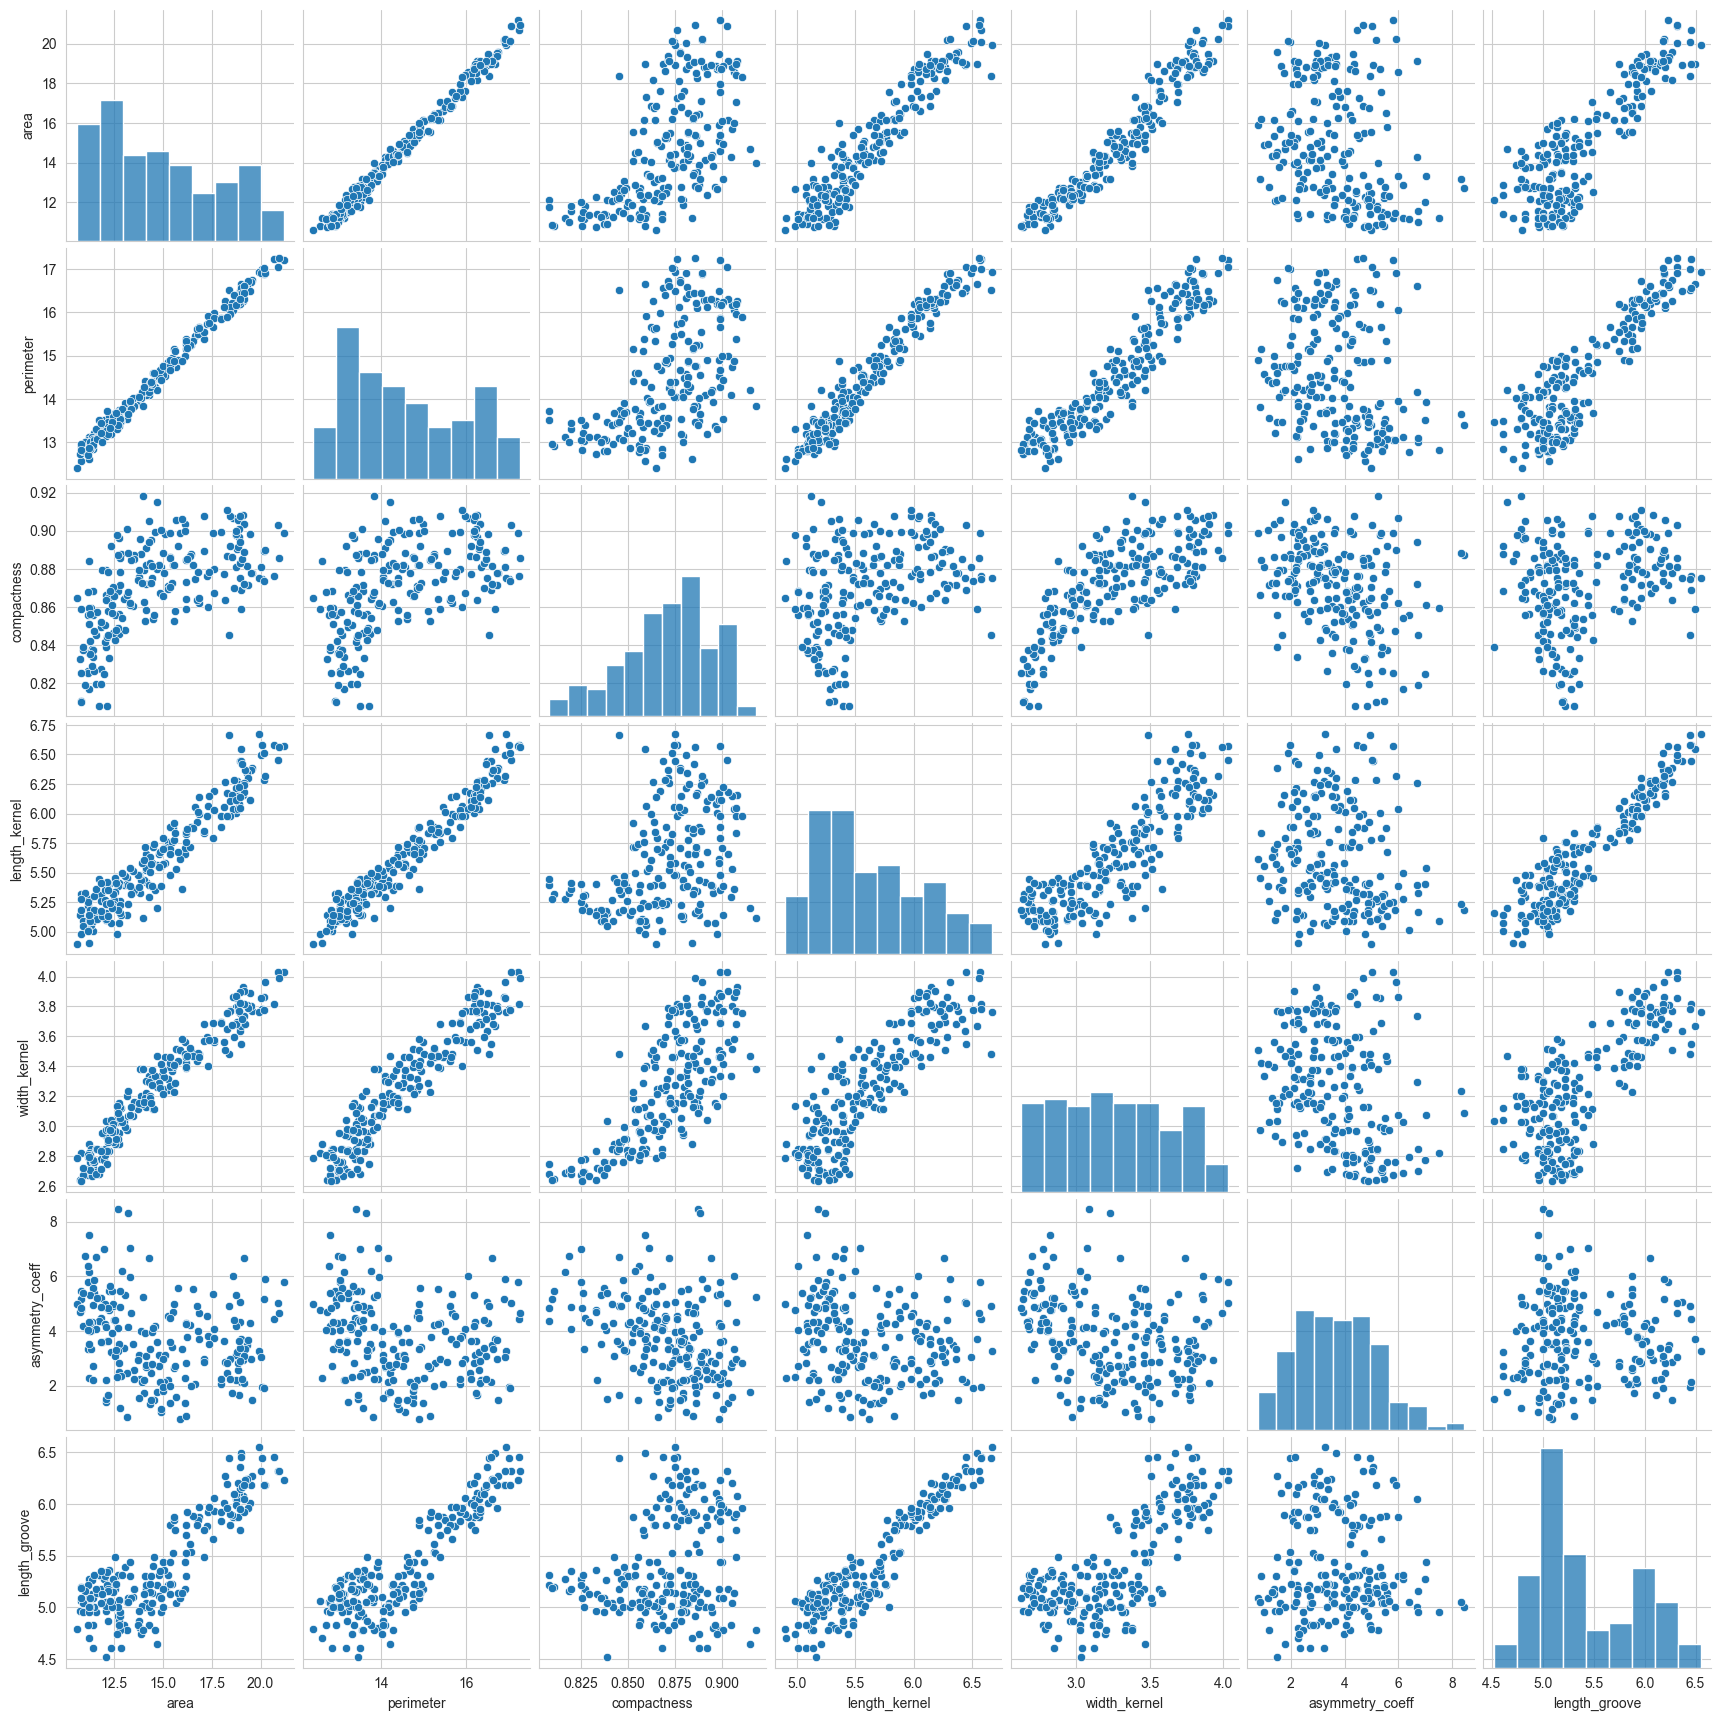

In [17]:
sns.pairplot(X)
plt.show()

In [18]:
from helper.selection import scan_k_metrics

seeds_metrics = scan_k_metrics(X=X_seeds_std, ks=range(2, 8), random_state=42)

display(seeds_metrics)

,k,inertia,silhouette,ch,db
0,2,659.935777,0.461466,255.317812,0.810186
1,3,430.816528,0.402437,249.654974,0.922088
2,4,371.653144,0.329197,202.930659,1.062899
3,5,336.243099,0.266052,172.806643,1.287628
4,6,296.325608,0.244537,161.598977,1.338337
5,7,264.905709,0.255544,153.912715,1.300333


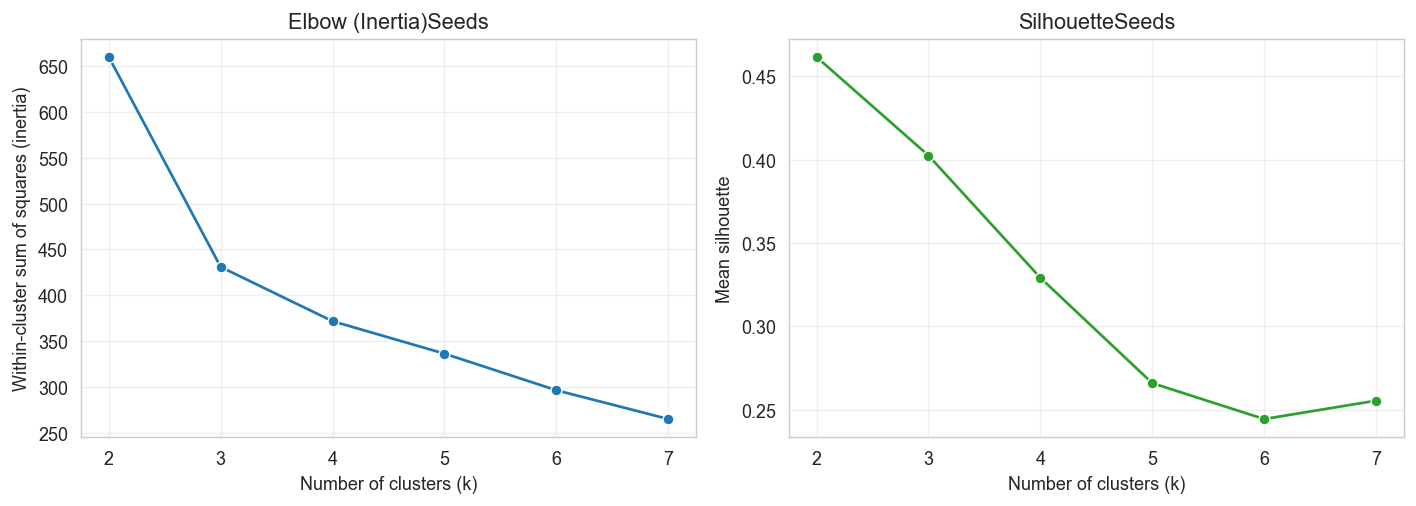

In [19]:
from helper.plotting import plot_elbow_silhouette

plot_elbow_silhouette(seeds_metrics, "Seeds")
plt.show()

In [20]:
from helper.report import k_report

r2_seeds = k_report(X_seeds_std, k=2, true_labels=y_true)
r3_seeds = k_report(X_seeds_std, k=3, true_labels=y_true)
r4_seeds = k_report(X_seeds_std, k=4, true_labels=y_true)

print({k: v for k, v in r2_seeds.items() if k != "model"})
print({k: v for k, v in r3_seeds.items() if k != "model"})
print({k: v for k, v in r4_seeds.items() if k != "model"})

{'k': 2, 'inertia': 659.935776644357, 'silhouette': 0.46146579826821466, 'CH': 255.3178118554645, 'DB': 0.8101856396961451, 'ARI': 0.5074767556450577, 'AMI': 0.5965282022051229, 'NMI': 0.5987304258201084}
{'k': 3, 'inertia': 430.81652834345675, 'silhouette': 0.4024370101867174, 'CH': 249.65497431126064, 'DB': 0.9220878143202835, 'ARI': 0.7971900801193832, 'AMI': 0.7476785330956146, 'NMI': 0.7498948838399828}
{'k': 4, 'inertia': 371.65314399951626, 'silhouette': 0.3291966792017614, 'CH': 202.930659038, 'DB': 1.062899481872673, 'ARI': 0.6388222022666139, 'AMI': 0.6441612534143376, 'NMI': 0.6484031171265918}


In [21]:
from sklearn.metrics import silhouette_score

# Suppose elbow and silhouette both support k=3
k = 3
kmeans = KMeans(n_clusters=k, n_init="auto", random_state=42)
labels = kmeans.fit_predict(X_seeds_std)

print("Inertia:", kmeans.inertia_)
print("Silhouette:", silhouette_score(X_seeds_std, labels))

Inertia: 430.81652834345675
Silhouette: 0.4024370101867174


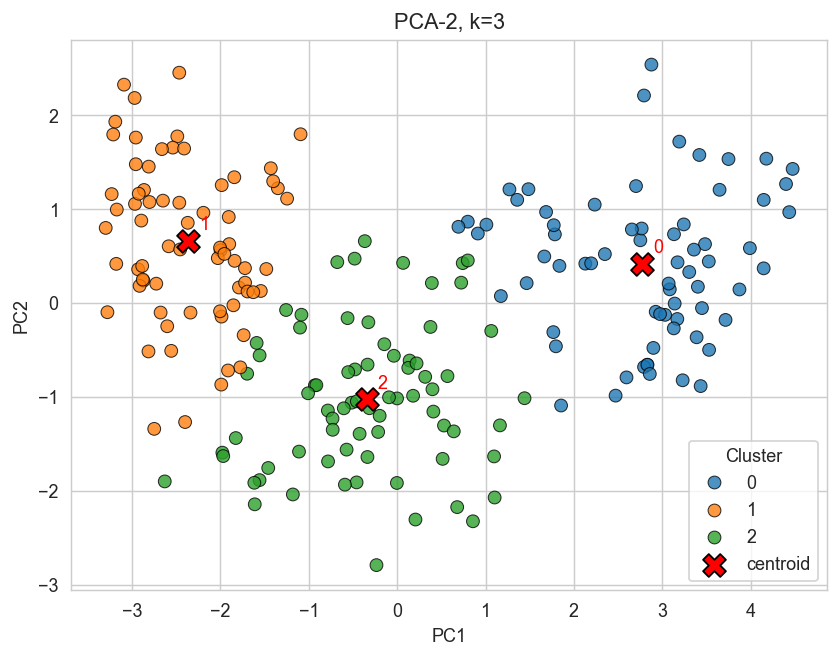

In [22]:
from helper.plotting import plot_kmeans_pca2

plot_kmeans_pca2(X_seeds_std, kmeans, title="PCA-2, k=3")
plt.show()

In [23]:
df_eval = pd.DataFrame({"Cluster": labels, "Variety": y_true})
ct = pd.crosstab(df_eval.Cluster, df_eval.Variety)
display(ct)

Variety,1,2,3
Cluster,,,
0,2,66,0
1,4,0,65
2,64,4,5


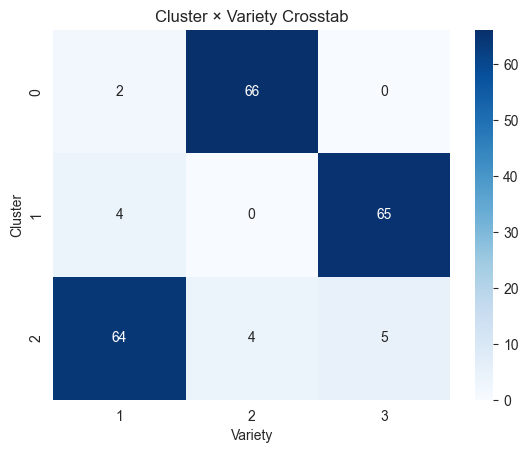

In [24]:
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues")
plt.title("Cluster × Variety Crosstab")
plt.show()

In [25]:
# Row-wise proportions for easier interpretation
ct_row = ct.div(ct.sum(axis=1), axis=0).round(2)
display(ct_row)

Variety,1,2,3
Cluster,,,
0,0.03,0.97,0.00
1,0.06,0.00,0.94
2,0.88,0.05,0.07


In [26]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(y_true, labels)
nmi = normalized_mutual_info_score(y_true, labels)
print(f"ARI = {ari:.3f} | NMI = {nmi:.3f}")

ARI = 0.797 | NMI = 0.750


## **Transforming Features for Better Clustering (Rebuilt Lecture)**

### **1. The Real Problem**

K-Means clustering minimises the within-cluster sum of squared *Euclidean* distances:

$$
J = \sum_{k=1}^{K} \sum_{x_i \in C_k} \| x_i - \mu_k \|^2
$$

where:

* $x_i$ = observation vector,
* $\mu_k$ = centroid of cluster $C_k$.

This formula treats **each feature equally in raw numerical scale**.
Therefore, if one feature (say, *proline*) has values in the thousands and another (say, *malic acid*) varies around 1, the larger-scaled feature dominates the distance computation.
In other words:

> In K-Means, **variance equals influence**.

That's why scaling isn't just cosmetic; it fundamentally changes the cluster geometry.


### **2. Dataset — The Real Piedmont Wines**

The *Wine* dataset from UCI Machine Learning Repository:

* 178 samples from *Barolo*, *Grignolino*, and *Barbera* wines.
* 13 continuous features from chemical analysis.

```python
import pandas as pd
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)
X = wine.data
y_true = wine.target
feature_names = wine.feature_names
print(X.head())
print(wine.target_names)
```

This dataset is the canonical example of scaling issues because *proline*’s variance is 5–6 orders of magnitude higher than most features.

### **3. Step One — Quantifying the Problem**

Before doing anything, measure the **spread** (variance and range) of each feature.

```python
X.describe().loc[['mean', 'std', 'min', 'max']].T.sort_values('std', ascending=False)
```

You’ll see:

* `proline` std ≈ 518
* `flavanoids` std ≈ 1
* `color_intensity` std ≈ 2

A single feature (proline) swamps the geometry.
Let’s confirm that visually.

```python
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data=X[['proline', 'alcohol', 'flavanoids', 'color_intensity']])
plt.title("Unscaled Feature Distributions (notice different magnitudes)")
plt.show()
```

If you cluster this dataset **without scaling**, the algorithm primarily separates wines by *proline*, ignoring all subtler dimensions.

### **4. Step Two — Clustering Without Scaling**

```python
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

kmeans_raw = KMeans(n_clusters=3, n_init='auto', random_state=42)
labels_raw = kmeans_raw.fit_predict(X)

print("Inertia:", kmeans_raw.inertia_)
print("Silhouette:", silhouette_score(X, labels_raw))
print("ARI:", adjusted_rand_score(y_true, labels_raw))
```

> You’ll likely get **ARI ≈ 0.2–0.3** — meaning almost random alignment with true varieties.

Let’s also examine cross-tabulation.

```python
pd.crosstab(labels_raw, y_true)
```

It will look chaotic, like DataCamp’s example (`Barbera` and `Grignolino` tangled).


## **5. Step Three — Standardising Features**

Now apply **StandardScaler**, which transforms each feature:

$$
z = \frac{x - \bar{x}}{s}
$$

where $\bar{x}$ is the mean and $s$ is the standard deviation.

After scaling, each column has mean 0 and variance 1.

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names)
X_scaled_df.describe().loc[['mean', 'std']].T
```

All means ≈ 0, stds ≈ 1 — now features contribute equally to distance.

### **6. Step Four — Scaled Clustering**

```python
kmeans_scaled = KMeans(n_clusters=3, n_init='auto', random_state=42)
labels_scaled = kmeans_scaled.fit_predict(X_scaled)

print("Inertia:", kmeans_scaled.inertia_)
print("Silhouette:", silhouette_score(X_scaled, labels_scaled))
print("ARI:", adjusted_rand_score(y_true, labels_scaled))
```

> You’ll now see **ARI ≈ 0.9**, **Silhouette ≈ 0.55**, a dramatic improvement.

```python
pd.crosstab(labels_scaled, y_true)
```

You’ll observe near-perfect alignment of clusters with varieties — the effect of equalised feature influence.

### **7. Step Five — Pipelines for Elegance**

The scaling + clustering pattern appears constantly in machine learning.
Rather than calling `.fit_transform()` manually, scikit-learn offers **pipelines** that automate the flow of data through sequential steps.

```python
from sklearn.pipeline import make_pipeline

pipeline = make_pipeline(StandardScaler(), KMeans(n_clusters=3, n_init='auto', random_state=42))
pipeline.fit(X)

labels_pipe = pipeline.predict(X)
print("ARI:", adjusted_rand_score(y_true, labels_pipe))
```

The pipeline:

1. Fits the scaler on `X` and transforms it;
2. Passes the scaled data into KMeans;
3. Allows you to `fit()` and `predict()` with the same syntax as a single estimator.

### **8. Step Six — Visual Comparison**

To appreciate scaling’s geometric impact:

```python
from sklearn.decomposition import PCA

def plot_pca(X_data, labels, title):
    pca = PCA(n_components=2)
    Z = pca.fit_transform(X_data)
    sns.scatterplot(x=Z[:,0], y=Z[:,1], hue=labels, palette="Set2")
    plt.title(title)
    plt.show()

plot_pca(X, labels_raw, "PCA – Raw Features")
plot_pca(X_scaled, labels_scaled, "PCA – Scaled Features")
```

In the *raw* plot, clusters smear along one high-variance axis (proline).
In the *scaled* plot, structure reappears, separating three distinct, compact clusters.


### **9. Step Seven — Quantitative Comparison**

| Metric     | Raw   | Scaled     |
| ---------- | ----- | ---------- |
| Inertia    | High  | Much lower |
| Silhouette | ~0.25 | **~0.55**  |
| ARI        | 0.25  | **0.9**    |
| NMI        | 0.35  | **0.88**   |

> Feature standardisation didn’t just make the plot “look better”; it restored meaningful geometry.


### **10. Discussion**

#### **Why this matters conceptually**

* KMeans assumes **isotropic** (spherical) clusters in Euclidean space.
* Scaling ensures isotropy across features, preventing any dimension from dominating.
* In many real datasets (especially chemical, physical, or economic), magnitudes differ drastically, so scaling is not optional — it’s *a precondition* for meaningful distance-based learning.

#### **When not to scale**

* If your features are already **dimensionless ratios** or share the same physical units (e.g., all percentages).
* Or when interpretability in the original scale matters (e.g., clustering income levels).


In [31]:
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)
X = wine.data
X_raw = X.copy()
y_true = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

print(f"Shape: {X.shape}")
print("Features:", feature_names)
print("Target classes:", target_names)

Shape: (178, 13)
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Target classes: ['class_0' 'class_1' 'class_2']


## **Tasks**

### **Task 1 – Quantify the Scaling Problem**

Compute and inspect the variance and range of each feature.
Identify which variables are most likely to dominate K-Means distance computations.


In [49]:
X

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


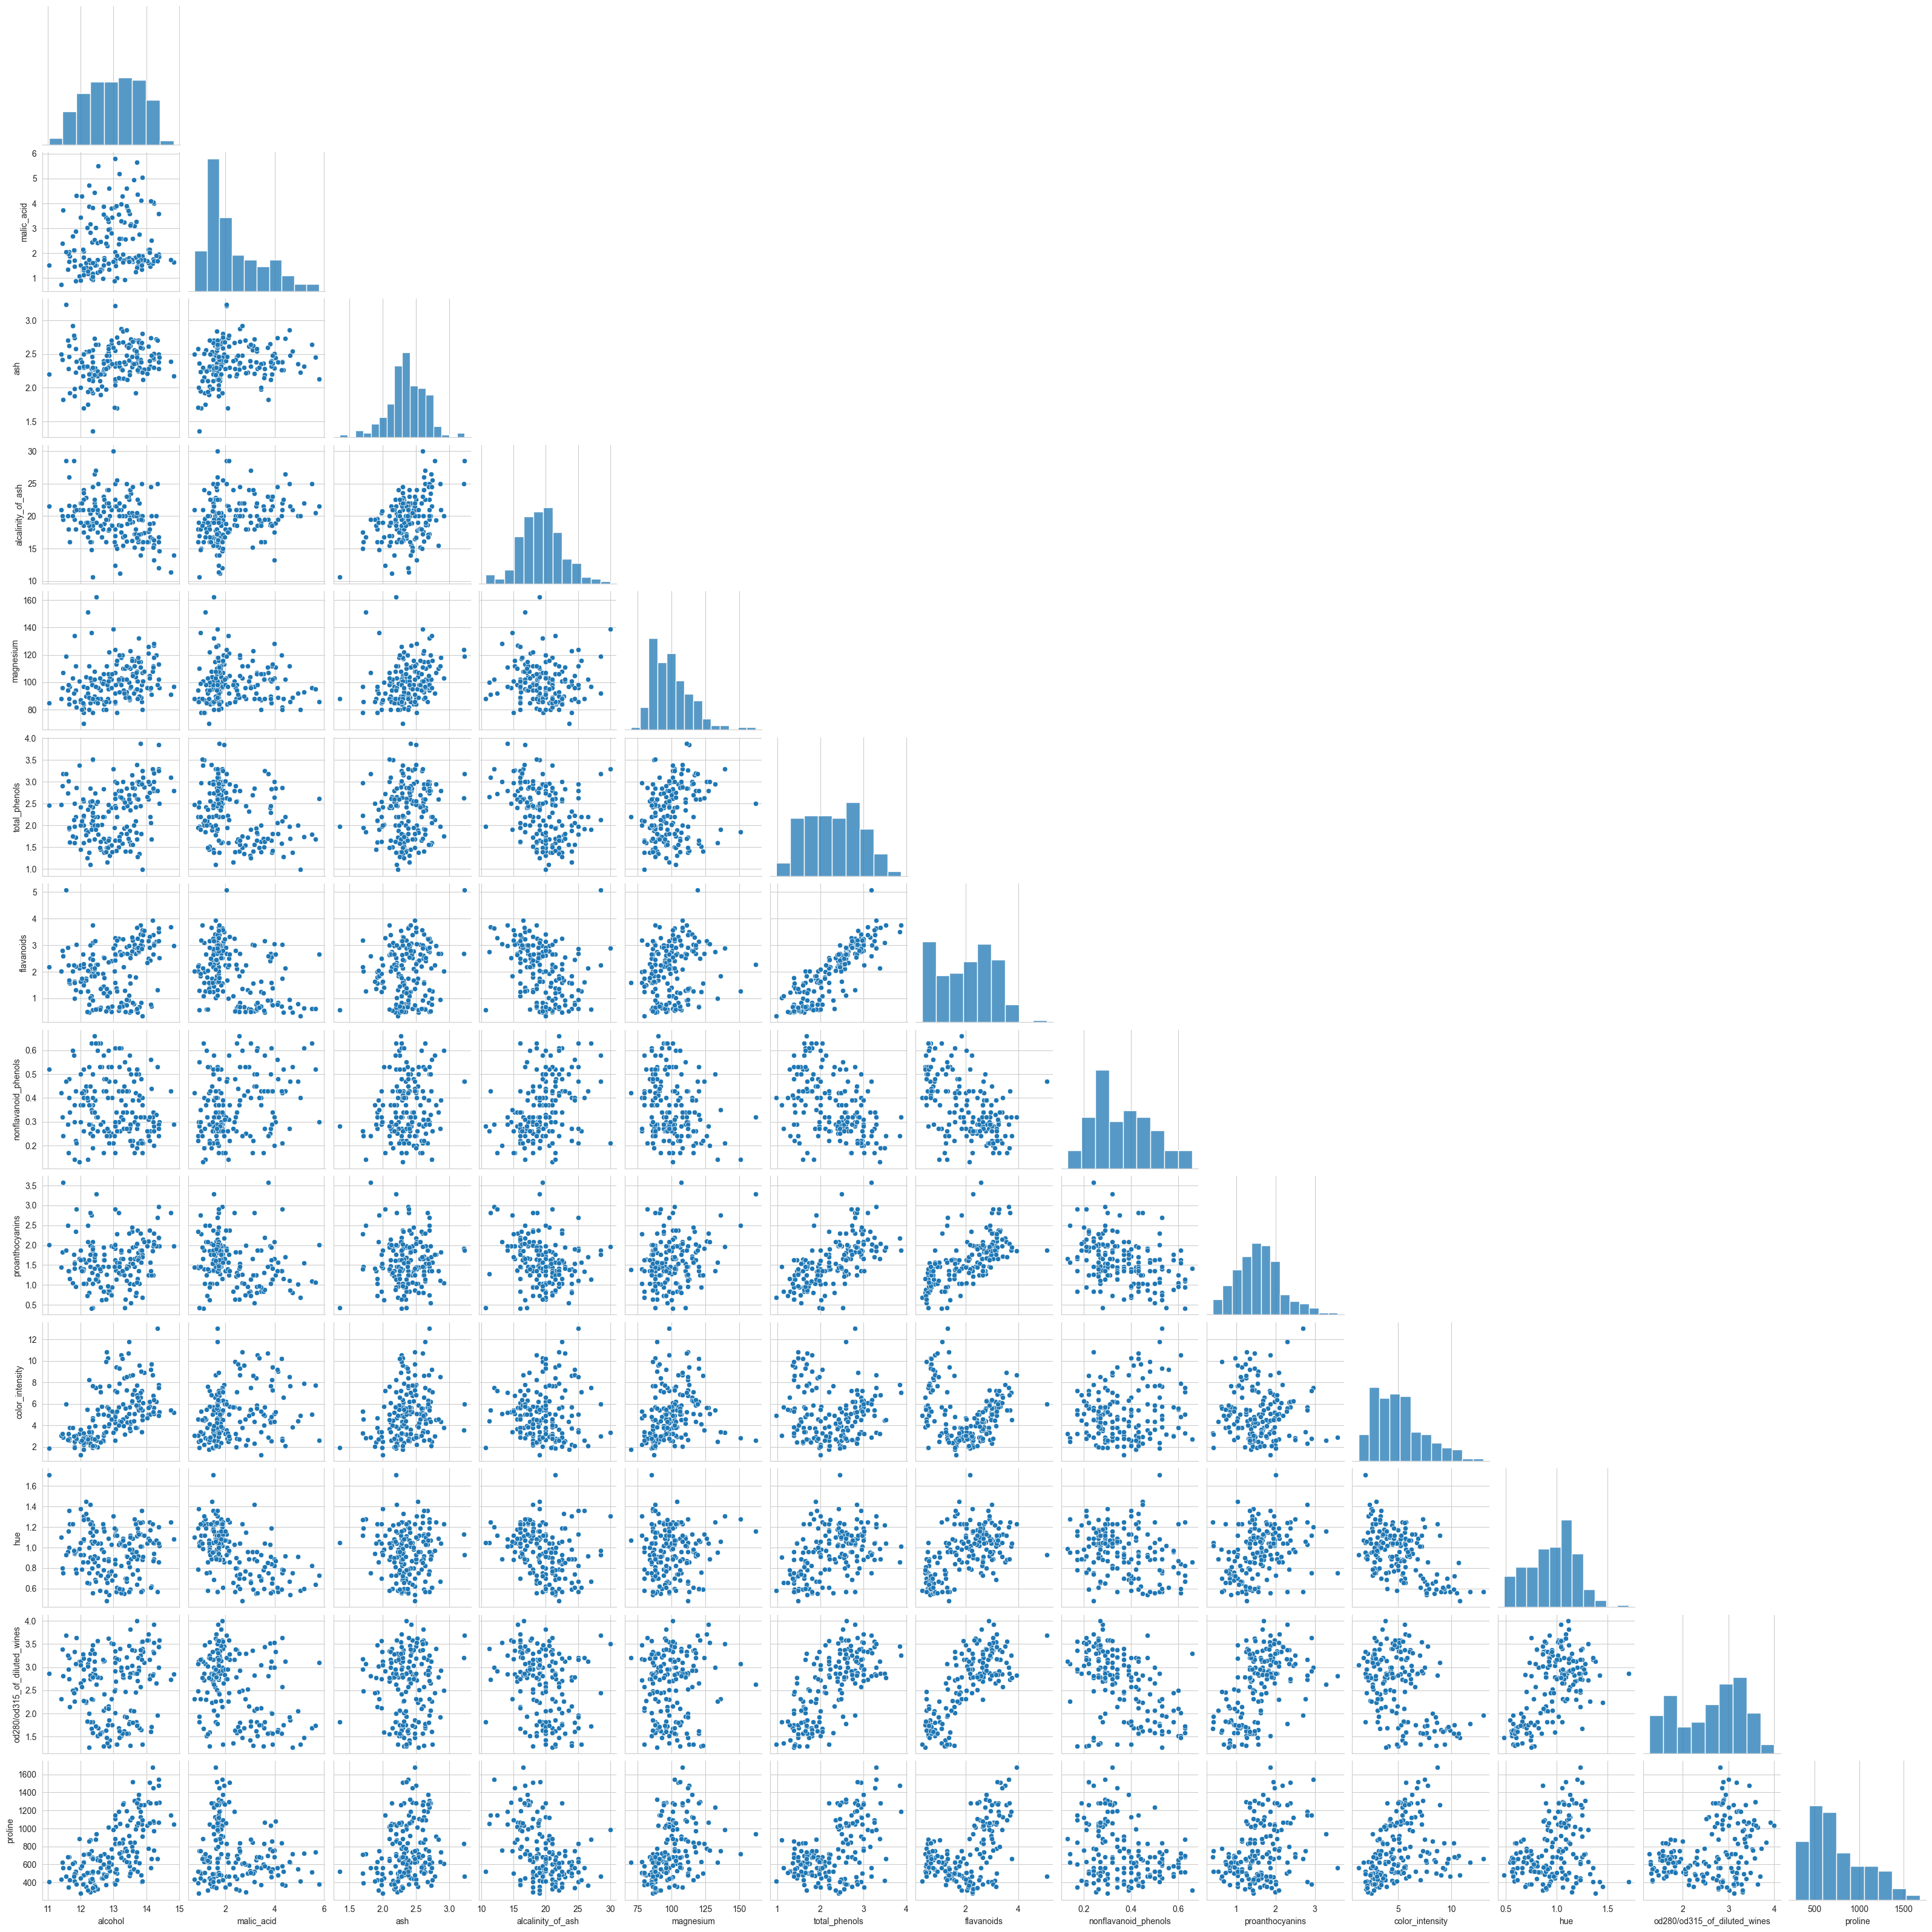

In [34]:
sns.pairplot(X, corner=True)
plt.show()

In [35]:
X.var()

alcohol                             0.659062
malic_acid                          1.248015
ash                                 0.075265
alcalinity_of_ash                  11.152686
magnesium                         203.989335
total_phenols                       0.391690
flavanoids                          0.997719
nonflavanoid_phenols                0.015489
proanthocyanins                     0.327595
color_intensity                     5.374449
hue                                 0.052245
od280/od315_of_diluted_wines        0.504086
proline                         99166.717355
dtype: float64

### **Task 2 – Baseline Clustering (Unscaled)**

Fit K-Means (k=3) directly on the raw data.
Assess cluster quality using at least **two internal metrics** (e.g. inertia, silhouette) and **one external metric** (ARI or NMI).
Show the cross-tabulation between clusters and true classes.

Deliverables:

* Metric table (inertia, silhouette, ARI/NMI).
* Crosstab visualisation (heatmap or DataFrame).

In [43]:
from sklearn.cluster import KMeans

km_raw = KMeans(n_clusters=3)

km_raw.fit(X_raw)

labels_raw = km_raw.predict(X_raw)

In [55]:
from helper.report import k_report

unscaled_r3 = k_report(X_raw, k=3, true_labels=y_true)

unscaled_r3 = {k: v for k, v in unscaled_r3.items() if k != "model"}
print(f"Unscaled: {unscaled_r3}")

Unscaled: {'k': 3, 'inertia': 2633555.3324093386, 'silhouette': 0.5595823478987215, 'CH': 497.00487620805814, 'DB': 0.549557597464291, 'ARI': 0.3517721516862617, 'AMI': 0.4167590924073939, 'NMI': 0.423309269344735}


c:\Users\jhonm\.conda\envs\datacamp\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


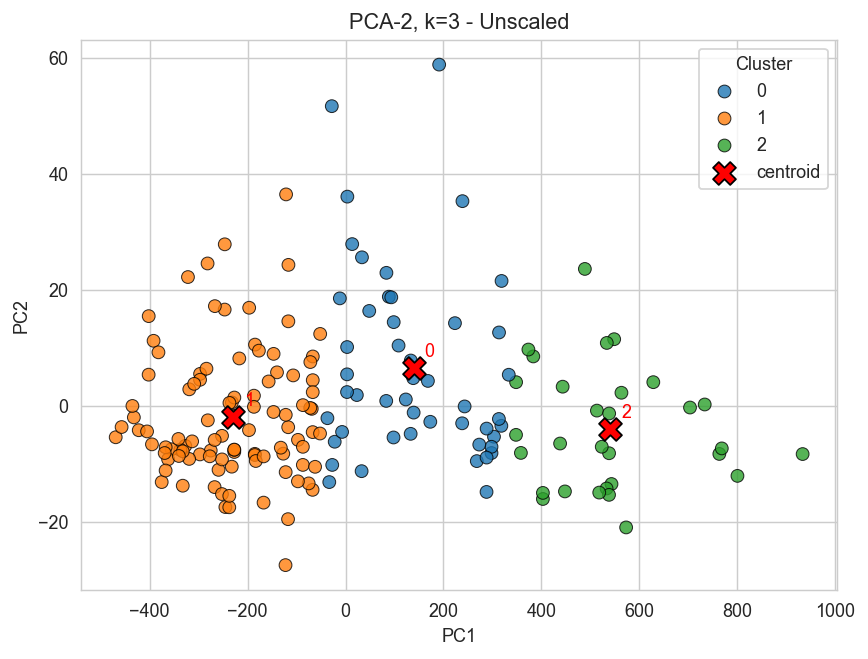

In [50]:
from helper.plotting import plot_kmeans_pca2

plot_kmeans_pca2(X_raw, km_raw, title="PCA-2, k=3 - Unscaled")
plt.show()

### **Task 3 – Feature Standardisation**

Standardise features using an appropriate scaler (you choose which, but justify it).
Then rerun the same clustering procedure.

Deliverables:

* Scaler choice + reasoning.
* New metrics and crosstab.
* Quantitative and qualitative comparison to the unscaled results.

In [57]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# The wine dataset has features on different scales; StandardScaler is appropriate
# to equalise mean and variance before distance-based clustering.
scaler_wine = StandardScaler()
km_wine = KMeans(n_clusters=3, random_state=42)

X_wine_std = scaler.fit_transform(X)
km_wine.fit(X_wine_std)
labels = km_wine.predict(X_wine_std)

In [58]:
from helper.report import k_report

r3_wine = k_report(X_wine_std, k=3, true_labels=y_true)

scaled_r3 = {k: v for k, v in r3_wine.items() if k != "model"}
print(f"Unscaled: {unscaled_r3}")
print(f"Scaled: {scaled_r3}")

Unscaled: {'k': 3, 'inertia': 2633555.3324093386, 'silhouette': 0.5595823478987215, 'CH': 497.00487620805814, 'DB': 0.549557597464291, 'ARI': 0.3517721516862617, 'AMI': 0.4167590924073939, 'NMI': 0.423309269344735}
Scaled: {'k': 3, 'inertia': 1277.928488844642, 'silhouette': 0.2848589191898987, 'CH': 70.94000800315118, 'DB': 1.3891879777181648, 'ARI': 0.8974949815093207, 'AMI': 0.874579440437926, 'NMI': 0.8758935341223069}


### Key Takeaways

1. **Never compare inertia across different scalings** - the units are different!
2. **Trust external validation** (ARI/AMI) over internal metrics when you have ground truth
3. **Scaling is CRITICAL** for K-means when features have different units/scales
4. **The scaled clustering is actually excellent** - those ~0.90 scores are very good!

### **Task 4 – Pipeline Construction**

Implement the entire transformation + clustering process as a **scikit-learn pipeline**.
Verify that the results match your previous step.

Deliverables:

* A clean, reusable pipeline.

In [59]:
from sklearn.pipeline import make_pipeline

pipe_wine = make_pipeline(scaler_wine, km_wine)

### **Task 5 – Visual Evidence**

Project the data into two dimensions (PCA, t-SNE, or UMAP).
Compare geometric structure of raw vs. scaled features.

Deliverables:

* Two scatterplots (before and after scaling).
* A concise written reflection:
  “How does scaling change the geometric interpretation of distance and shape?”

c:\Users\jhonm\.conda\envs\datacamp\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


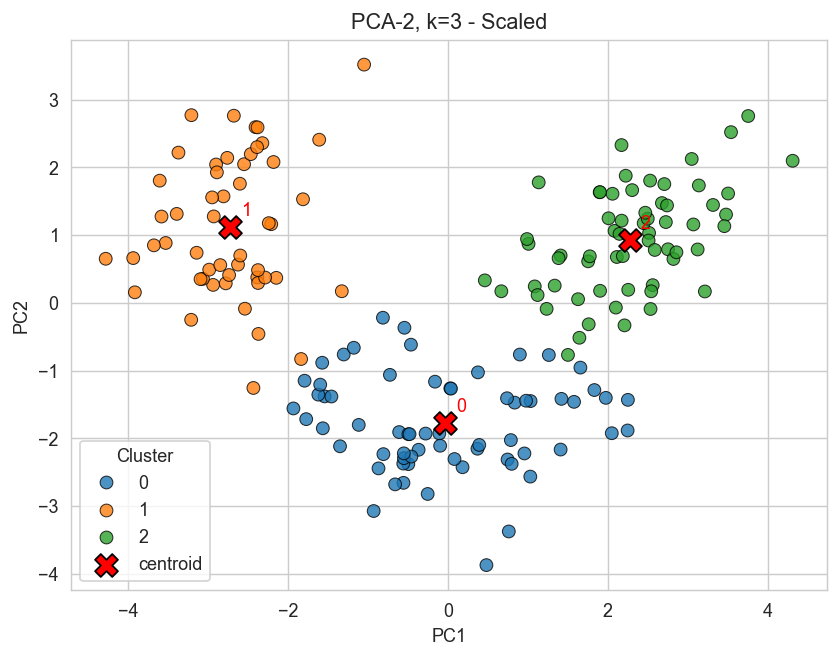

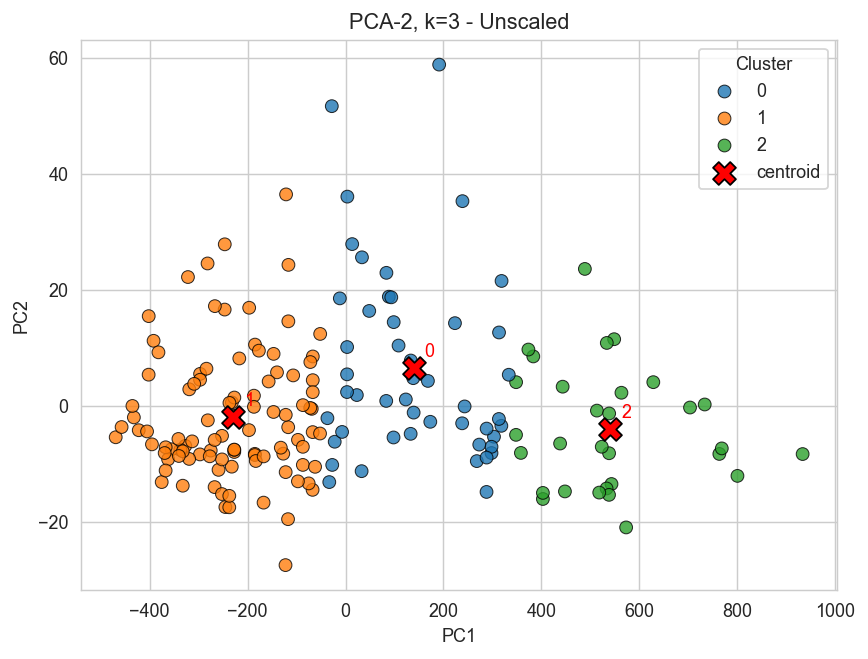

In [53]:
from helper.plotting import plot_kmeans_pca2

plot_kmeans_pca2(X_wine_std, km, title="PCA-2, k=3 - Scaled")
plot_kmeans_pca2(X_raw, km_raw, title="PCA-2, k=3 - Unscaled")
plt.show()

### **Task 6 – Comparative Experiment**

Repeat the pipeline using **at least one alternative scaling technique** (`MinMaxScaler`, `RobustScaler`, or `Normalizer`).
Analyse whether the cluster assignments or metrics change meaningfully.

Deliverables:

* Comparative table (scaler, silhouette, ARI/NMI, inertia).
* Your interpretation of the most suitable scaling strategy for this dataset.

> it doesn't make any sense to use any of those scaling techniques, after reading the official documentation it's crystal clear when and why I should use each.

## 1) Why hierarchical clustering is useful

K-means gives you one flat partition for a chosen (k). In many domains, the structure is **nested**: fine-grained groups within broader families (e.g., grape varieties within regions; product segments within markets). **Agglomerative hierarchical clustering (HC)** builds exactly such a *nested* sequence of merges. The output—the **dendrogram**—is a compact visual audit of “who joined whom, and at what dissimilarity”.

Good uses in practice:

* exploratory grouping of countries by macro indicators, customers by baskets, genes by expression profiles, or assets by co-movement;
* **feature** clustering (group strongly related variables before modelling);
* transparent, meeting-friendly graphics where the audience wants to *see* relationships.
## 2) Foundations: distances, linkages, and the algorithm

Let $X=\{x_1,\dots,x_n\}$ be your samples in $\mathbb{R}^d$. Choose a *dissimilarity* $D(x_i,x_j)$ (Euclidean by default; cosine/correlation for "shape" similarity; Gower for mixed types). Define a **linkage** $L(A,B)$ that turns two clusters $A,B\subset X$ into a single number.

Common linkages:

* **Single**: $L_{\min}(A,B)=\min_{a\in A,b\in B} D(a,b)$ (prone to chaining).
* **Complete**: $L_{\max}(A,B)=\max_{a\in A,b\in B} D(a,b)$ (compact, sensitive to outliers).
* **Average/UPGMA**: mean pairwise distance across $A\times B$.
* **Ward**: merges $A,B$ that **minimise the increase in within-cluster SSE**:
  $$
  \Delta(A,B) = \frac{|A||B|}{|A|+|B|}\|\mu_A-\mu_B\|_2^2,
  $$
  where $\mu_A$ is the mean of $A$. Ward **requires Euclidean geometry** and tends to yield spherical, k-means-like groups.

**Agglomerative algorithm (sketch)**

1. Start with $n$ singleton clusters.
2. Repeatedly merge the pair $(A,B)$ with smallest $L(A,B)$.
3. Record the merge "height" (the value of $L$ at merge time). Continue until one cluster remains.

Complexity: storing the distance structure is $O(n^2)$ memory; with modern implementations, time is $O(n^2)$. This is not a big-data method; subsample or pre-embed for $n\gtrsim 10^4$.

## 3) How to read a dendrogram (and what *not* to read into it)

* The **height** where two branches meet is the dissimilarity at which those clusters first become indistinguishable, given your metric and linkage.
* The **x-axis order is arbitrary** (leaves can be flipped at each merge without changing the tree).
* Cutting the tree at height (h) yields a **flat partition**. Alternatively, specify the **number of clusters** to cut.
* Do not interpret heights as probabilities, p-values, or “strength of evidence”. They are pure geometry.

## 4) Pre-processing and metric choice

* **Standardise** features before Euclidean distance; otherwise high-variance columns dominate.
* Use **cosine/correlation** dissimilarity when *direction/shape* matters more than magnitude (e.g., time-series co-movement across entities).
* For mixed numeric/categorical data: compute **Gower** distances (via `gower` package) or design a domain-specific similarity.

## 5) Python—clean, readable patterns


### 5.1 Wine (UCI, via scikit-learn): Ward linkage on scaled chemistry

```python
from __future__ import annotations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist
from scipy.cluster import hierarchy as sch

# data 
wine = load_wine(as_frame=True)
X = wine.data
y = wine.target
labels_true = pd.Series(y).map(dict(enumerate(wine.target_names)))

# scale for Euclidean geometry (Ward) 
Z = StandardScaler().fit_transform(X)

# Ward internally uses Euclidean metric on the raw observations; pdist is optional here.
merges = linkage(Z, method="ward")

# dendrogram
fig, ax = plt.subplots(figsize=(10, 5), dpi=130)
dendrogram(
    merges,
    labels=labels_true.index.astype(str).to_numpy(),  # sample indices (short)
    leaf_rotation=90, leaf_font_size=7, ax=ax,
)
ax.set_title("Wine samples – Ward linkage on scaled features")
ax.set_ylabel("Dissimilarity (Ward)")
plt.tight_layout(); plt.show()

# choose a flat partition: e.g. k=3 to compare to varieties
k = 3
labels_hc = fcluster(merges, t=k, criterion="maxclust")

# external audit (only because Wine has ground truth) 
ari = adjusted_rand_score(y, labels_hc)
nmi = normalized_mutual_info_score(y, labels_hc)
print(f"ARI={ari:.3f}  NMI={nmi:.3f}")

# fidelity of the tree itself (cophenetic correlation)
coph_dists, coph_links = sch.cophenet(merges, pdist(Z, metric="euclidean"))
print(f"Cophenetic correlation (tree vs. pairwise distances): {coph_dists:.3f}")

# feature clustering variant (cluster columns by correlation)
corr = X.corr()
sns.clustermap(
    corr, center=0, cmap="vlag", linewidths=.2,
    row_cluster=True, col_cluster=True, figsize=(8, 8)
)
plt.show()
```

**What to look for.** With Ward on scaled chemistry, a cut at (k=3) typically aligns well with varieties. The **cophenetic correlation** quantifies how faithfully the tree preserves pairwise dissimilarities (closer to 1 is better). The **clustermap** demonstrates hierarchical clustering of *features*—handy for spotting redundant blocks before modelling.

### 5.2 Penguins (seaborn): effect of linkage choice

```python
import seaborn as sns
from scipy.spatial.distance import pdist, squareform

peng = sns.load_dataset("penguins").dropna()
Xpeng = peng[["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"]].to_numpy()
ypeng = peng["species"].to_numpy()

Xpeng_z = StandardScaler().fit_transform(Xpeng)

# compare linkages on the same metric 
for method in ["single", "complete", "average", "ward"]:
    Z = linkage(Xpeng_z, method=method)  # Euclidean metric by default
    labs = fcluster(Z, t=3, criterion="maxclust")
    ari = adjusted_rand_score(ypeng, labs)
    print(f"{method:>8}  ARI={ari:.3f}")

    fig, ax = plt.subplots(figsize=(9, 4), dpi=130)
    dendrogram(Z, no_labels=True, ax=ax)
    ax.set_title(f"Penguins – {method} linkage (scaled features)")
    ax.set_ylabel("Dissimilarity")
    plt.tight_layout(); plt.show()
```

You will generally see **single** succumb to chaining (long thin branches), **complete** produce very compact clusters but split more aggressively, **average** behave moderately, and **Ward** mirror k-means-like geometry. The external ARI validates which picture aligns with species.

## 6) Cutting trees responsibly

“Where do I cut?” is not answered by the dendrogram alone.

* **By number of clusters**: `fcluster(Z, t=k, criterion="maxclust")`.
* **By height**: choose a threshold (h); everything merged above that stays separate below.
* **By inconsistency** (SciPy’s `inconsistent`): cut branches that are much taller than their local neighbourhood.
* **By external or internal metrics**: compute silhouette/DB/CH on the flat assignments across a grid of cut levels, then choose a principled point (and report it).

```python
from sklearn.metrics import silhouette_score

def silhouette_over_heights(Z, X, heights):
    out = []
    for h in heights:
        labs = fcluster(Z, t=h, criterion="distance")
        if len(np.unique(labs))>1:
            out.append((h, silhouette_score(X, labs)))
    return pd.DataFrame(out, columns=["height","silhouette"])

Z_wine = linkage(StandardScaler().fit_transform(X), method="ward")
heights = np.linspace(5, 50, 20)  # sensible range depends on your data
sil_df = silhouette_over_heights(Z_wine, StandardScaler().fit_transform(X), heights)
print(sil_df.sort_values("silhouette", ascending=False).head())
```

## 7) Choosing metric and linkage for real problems

* **If your notion of similarity is “parallel movement regardless of scale”** (e.g., daily log-return *shape* for equities), use **cosine** or **correlation distance** with **average/complete** linkage. Do *not* use Ward.

  ```python
  D = pdist(returns.T, metric="correlation")   # stocks × time
  Z = linkage(D, method="average")             # pass precomputed distances
  ```
* **If your notion is “overall Euclidean closeness across many comparable features”**, scale then use **Ward**.
* **If you care about outliers** (you do): single is fragile; complete is robust but can split multi-modal clusters; average is often a decent compromise.

## 8) Relation to t-SNE (and a sober warning)

t-SNE is not a clustering algorithm. It is a *non-linear embedding* that arranges points in 2-D using a perplexity-controlled local similarity. t-SNE **distorts global geometry on purpose** to reveal local neighbourhoods; distances between far-apart blobs are not meaningful. If you plot t-SNE and then draw clusters around blobs, be explicit that the “clusters” are a visual heuristic. When you need a partition, compute it from the **original space** and use t-SNE only for illustration.

## 9) Anti-patterns and pitfalls

* Interpreting the dendrogram x-order as meaningful.
* Using **Ward with non-Euclidean metrics** (mathematically inconsistent).
* Skipping scaling for Euclidean distances.
* Reading heights as statistical significance.
* Over-crowded dendrograms (hundreds of leaves) that nobody can read—subsample, or cluster the *centroids* of a prior k-means.

## 10) A compact helper you can reuse

When you need a clean summary in a notebook:

```python
from dataclasses import dataclass
@dataclass
class HCReport:
    method: str
    metric: str
    ari: float | None
    nmi: float | None

def hc_fit_evaluate(X: np.ndarray, *, method="ward", metric="euclidean",
                    labels_true: np.ndarray | None=None, cut="maxclust", t=3) -> HCReport:
    """
    Fit hierarchical clustering and (optionally) evaluate against labels_true.
    """
    # For Ward, metric must be Euclidean on observations (not on a distance matrix).
    if method == "ward" and metric != "euclidean":
        raise ValueError("Ward requires Euclidean metric on raw observations.")
    Z = linkage(X, method=method, metric=metric)
    labs = fcluster(Z, t=t, criterion=cut)
    ari = adjusted_rand_score(labels_true, labs) if labels_true is not None else None
    nmi = normalized_mutual_info_score(labels_true, labs) if labels_true is not None else None
    return HCReport(method, metric, ari, nmi)
```

Example:

```python
Xz = StandardScaler().fit_transform(X)
print(hc_fit_evaluate(Xz, method="ward", labels_true=y, t=3))
print(hc_fit_evaluate(Xz, method="average", metric="euclidean", labels_true=y, t=3))
```

### Where this shows up in real projects

* **Customer analytics**: cluster products by co-purchase (use cosine on item vectors); dendrogram guides catalogue curation.
* **Bioinformatics**: Ward on scaled expression levels; clustermaps of genes × samples with clear block structure.
* **Risk and portfolio**: cluster assets by correlation distance to build nested risk factors; cut the tree to define “risk buckets”.
* **Feature engineering**: cluster highly correlated features and pick one representative from each block to reduce multicollinearity.